# Modulo 2: Deteccion y Tracking de Personas con YOLO

Este notebook toma una muestra aleatoria del 15% del manifest y genera los tracks limpios para el resto del pipeline


## Librerias y parametros de tracking


In [4]:
from pathlib import Path
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd().parent

VIDEO_MANIFEST_PATH = PROJECT_ROOT / "outputs" / "ingesta" / "video_manifest.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tracking"
SAMPLED_MANIFEST_PATH = OUTPUT_DIR / "video_manifest_tracking_15pct.csv"
YOLO_MODEL_PATH = PROJECT_ROOT / "yolo11n.pt"

TRACKING_SAMPLE_RATIO = 0.15
RANDOM_SEED = 21
PERSON_CLASS_ID = 0
TRACKER_NAME = "botsort.yaml"
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.50
PERSIST_TRACKS = True
SAVE_PREVIEW = True
MIN_TRACK_LENGTH_FRAMES = 5
DEVICE = None
VERBOSE = False

pd.Series(
    {
        "VIDEO_MANIFEST_PATH": str(VIDEO_MANIFEST_PATH),
        "SAMPLED_MANIFEST_PATH": str(SAMPLED_MANIFEST_PATH),
        "YOLO_MODEL_PATH": str(YOLO_MODEL_PATH),
        "TRACKING_SAMPLE_RATIO": TRACKING_SAMPLE_RATIO,
        "RANDOM_SEED": RANDOM_SEED,
        "PERSON_CLASS_ID": PERSON_CLASS_ID,
        "TRACKER_NAME": TRACKER_NAME,
        "CONF_THRESHOLD": CONF_THRESHOLD,
        "IOU_THRESHOLD": IOU_THRESHOLD,
        "PERSIST_TRACKS": PERSIST_TRACKS,
        "SAVE_PREVIEW": SAVE_PREVIEW,
        "MIN_TRACK_LENGTH_FRAMES": MIN_TRACK_LENGTH_FRAMES,
        "DEVICE": DEVICE,
        "VERBOSE": VERBOSE,
    }
)

VIDEO_MANIFEST_PATH        c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...
SAMPLED_MANIFEST_PATH      c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...
YOLO_MODEL_PATH            c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...
TRACKING_SAMPLE_RATIO                                                   0.15
RANDOM_SEED                                                               21
PERSON_CLASS_ID                                                            0
TRACKER_NAME                                                    botsort.yaml
CONF_THRESHOLD                                                          0.25
IOU_THRESHOLD                                                            0.5
PERSIST_TRACKS                                                          True
SAVE_PREVIEW                                                            True
MIN_TRACK_LENGTH_FRAMES                                                    5
DEVICE                                                                  None

## Manifest original y muestra para tracking


In [5]:
video_manifest_df = pd.read_csv(VIDEO_MANIFEST_PATH)
video_manifest_df = video_manifest_df.sort_values(["split", "class_name", "video_id"]).reset_index(drop=True)

try:
    sampled_video_manifest_df = pd.read_csv(SAMPLED_MANIFEST_PATH)
    sample_source = "Manifest de muestra reutilizado"
except FileNotFoundError:
    sampled_parts = []

    for (split_name, class_name), group_df in video_manifest_df.groupby(["split", "class_name"]):
        sample_size = max(1, int(np.ceil(len(group_df) * TRACKING_SAMPLE_RATIO)))
        sampled_group_df = group_df.sample(n=sample_size, random_state=RANDOM_SEED).copy()
        sampled_parts.append(sampled_group_df)

    sampled_video_manifest_df = pd.concat(sampled_parts, ignore_index=True)
    sampled_video_manifest_df = sampled_video_manifest_df.sort_values(["split", "class_name", "video_id"]).reset_index(drop=True)
    sampled_video_manifest_df.to_csv(SAMPLED_MANIFEST_PATH, index=False)
    sample_source = "Manifest de muestra generado"

sampled_video_manifest_df = sampled_video_manifest_df.sort_values(["split", "class_name", "video_id"]).reset_index(drop=True)

print(f"Videos en el manifest original: {len(video_manifest_df)}")
print(f"Videos en la muestra para tracking: {len(sampled_video_manifest_df)}")
print(sample_source)
print(SAMPLED_MANIFEST_PATH)

display(sampled_video_manifest_df.head())

Videos en el manifest original: 328
Videos en la muestra para tracking: 51
Manifest de muestra reutilizado
c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIFICIAL\PROJECT\ENTREGA_3\outputs\tracking\video_manifest_tracking_15pct.csv


,split,class_name,video_path,video_id,fps_original,frame_count,duration_seconds,width,height
0,test,hurto_simulado,data/test/hurto_simulado/shop_lifter_46.mp4,test__hurto_simulado__shop_lifter_46,24.75,322,13.010101,704,576
1,test,hurto_simulado,data/test/hurto_simulado/shop_lifter_80.mp4,test__hurto_simulado__shop_lifter_80,24.75,223,9.010101,704,576
2,test,hurto_simulado,data/test/hurto_simulado/shop_lifter_95.mp4,test__hurto_simulado__shop_lifter_95,25.00,400,16.000000,704,576
3,test,normal,data/test/normal/shop_lifter_n_0_1.mp4,test__normal__shop_lifter_n_0_1,25.00,450,18.000000,704,576
4,test,normal,data/test/normal/shop_lifter_n_10.mp4,test__normal__shop_lifter_n_10,25.00,475,19.000000,704,576


## Distribucion de la muestra


In [6]:
processing_plan_df = (
    sampled_video_manifest_df.groupby(["split", "class_name"])
    .size()
    .reset_index(name="num_videos")
    .sort_values(["split", "class_name"])
    .reset_index(drop=True)
)
processing_plan_df


,split,class_name,num_videos
0,test,hurto_simulado,3
1,test,normal,5
2,train,hurto_simulado,12
3,train,normal,23
4,val,hurto_simulado,3
5,val,normal,5


## Peso base de YOLO

Si `yolo11n.pt` ya existe en la raiz del proyecto se reutiliza. Si no existe, se descarga y se guarda en esa ruta antes de cargar el modelo.


In [7]:
from ultralytics.utils.downloads import attempt_download_asset

if YOLO_MODEL_PATH.exists():
    print(f"Peso local encontrado: {YOLO_MODEL_PATH}")
else:
    print(f"No existe {YOLO_MODEL_PATH}. Se descargara el peso base yolo11n.pt desde Ultralytics.")
    attempt_download_asset(str(YOLO_MODEL_PATH), release="latest")
    if not YOLO_MODEL_PATH.exists():
        raise FileNotFoundError(f"No fue posible descargar el peso base en {YOLO_MODEL_PATH}")

model = YOLO(str(YOLO_MODEL_PATH))
model


Peso local encontrado: c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIFICIAL\PROJECT\ENTREGA_3\yolo11n.pt


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [8]:
model.names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

## Ejecucion del tracking sobre la muestra


In [9]:
RAW_TRACK_COLUMNS = [
    "split", "class_name", "video_id", "video_path", "frame_idx", "timestamp_sec",
    "track_id", "class_id", "confidence", "x1", "y1", "x2", "y2",
    "bbox_width", "bbox_height", "center_x", "center_y",
]

SUMMARY_COLUMNS = [
    "split", "class_name", "video_id", "track_id", "start_frame", "end_frame",
    "start_sec", "end_sec", "duration_sec", "num_detections", "mean_confidence",
    "mean_bbox_width", "mean_bbox_height",
]

if TRACKER_NAME in {"botsort", "bytetrack"}:
    TRACKER_NAME = f"{TRACKER_NAME}.yaml"

def format_duration(seconds: float) -> str:
    seconds = max(0.0, float(seconds))
    minutes, remaining_seconds = divmod(seconds, 60)
    hours, minutes = divmod(int(minutes), 60)
    if hours:
        return f"{hours}h {minutes:02d}m {remaining_seconds:05.2f}s"
    if minutes:
        return f"{minutes}m {remaining_seconds:05.2f}s"
    return f"{remaining_seconds:.2f}s"


all_raw_parts = []
all_clean_parts = []
tracking_timing_rows = []
total_videos_to_process = len(sampled_video_manifest_df)

for video_index, (_, video_row) in enumerate(sampled_video_manifest_df.iterrows(), start=1):
    split = str(video_row["split"])
    class_name = str(video_row["class_name"])
    video_id = str(video_row["video_id"])
    video_path = Path(video_row["video_path"])
    video_source_path = PROJECT_ROOT / video_path
    fps = float(video_row["fps_original"])
    video_output_dir = OUTPUT_DIR / split / video_id
    preview_path = video_output_dir / "tracking_preview.mp4"

    print(f"Procesando {video_index}/{total_videos_to_process}: {video_id}")
    video_start_time = time.perf_counter()

    track_kwargs = {
        "source": str(video_source_path),
        "stream": True,
        "persist": PERSIST_TRACKS,
        "tracker": TRACKER_NAME,
        "classes": [PERSON_CLASS_ID],
        "conf": CONF_THRESHOLD,
        "iou": IOU_THRESHOLD,
        "verbose": VERBOSE,
    }
    if DEVICE:
        track_kwargs["device"] = DEVICE

    results = model.track(**track_kwargs)
    raw_rows = []
    preview_writer = None

    try:
        for frame_idx, result in enumerate(results):
            if result.boxes is not None and len(result.boxes) > 0 and result.boxes.id is not None:
                boxes = result.boxes
                timestamp_sec = frame_idx / fps

                for detection_idx in range(len(boxes)):
                    class_id = int(boxes.cls[detection_idx].item())
                    if class_id != PERSON_CLASS_ID:
                        continue

                    track_id = int(boxes.id[detection_idx].item())
                    confidence = float(boxes.conf[detection_idx].item())
                    x1, y1, x2, y2 = boxes.xyxy[detection_idx].tolist()
                    bbox_width = x2 - x1
                    bbox_height = y2 - y1
                    center_x = x1 + (bbox_width / 2.0)
                    center_y = y1 + (bbox_height / 2.0)

                    raw_rows.append(
                        {
                            "split": split,
                            "class_name": class_name,
                            "video_id": video_id,
                            "video_path": video_path.as_posix(),
                            "frame_idx": int(frame_idx),
                            "timestamp_sec": round(timestamp_sec, 6),
                            "track_id": int(track_id),
                            "class_id": int(class_id),
                            "confidence": round(confidence, 6),
                            "x1": round(float(x1), 6),
                            "y1": round(float(y1), 6),
                            "x2": round(float(x2), 6),
                            "y2": round(float(y2), 6),
                            "bbox_width": round(float(bbox_width), 6),
                            "bbox_height": round(float(bbox_height), 6),
                            "center_x": round(float(center_x), 6),
                            "center_y": round(float(center_y), 6),
                        }
                    )

            if SAVE_PREVIEW:
                annotated_frame = result.plot()
                if preview_writer is None:
                    frame_height, frame_width = annotated_frame.shape[:2]
                    video_output_dir.mkdir(parents=True, exist_ok=True)
                    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
                    preview_writer = cv2.VideoWriter(str(preview_path), fourcc, fps, (frame_width, frame_height))
                preview_writer.write(annotated_frame)
    finally:
        if preview_writer is not None:
            preview_writer.release()

    raw_df = pd.DataFrame(raw_rows, columns=RAW_TRACK_COLUMNS) if raw_rows else pd.DataFrame(columns=RAW_TRACK_COLUMNS)

    if raw_df.empty:
        clean_df = pd.DataFrame(columns=RAW_TRACK_COLUMNS)
    else:
        valid_mask = (
            raw_df["track_id"].notna()
            & raw_df["x1"].notna()
            & raw_df["y1"].notna()
            & raw_df["x2"].notna()
            & raw_df["y2"].notna()
            & raw_df["bbox_width"].notna()
            & raw_df["bbox_height"].notna()
            & (raw_df["x2"] > raw_df["x1"])
            & (raw_df["y2"] > raw_df["y1"])
            & (raw_df["bbox_width"] > 0)
            & (raw_df["bbox_height"] > 0)
        )
        clean_df = raw_df.loc[valid_mask, RAW_TRACK_COLUMNS].copy()

        track_lengths = (
            clean_df.groupby(["split", "class_name", "video_id", "track_id"])
            .size()
            .reset_index(name="num_detections")
        )
        valid_tracks = track_lengths.loc[
            track_lengths["num_detections"] >= MIN_TRACK_LENGTH_FRAMES,
            ["split", "class_name", "video_id", "track_id"],
        ]
        clean_df = clean_df.merge(valid_tracks, on=["split", "class_name", "video_id", "track_id"], how="inner")
        clean_df = clean_df[RAW_TRACK_COLUMNS].sort_values(["split", "class_name", "video_id", "frame_idx", "track_id"]).reset_index(drop=True)

    if clean_df.empty:
        summary_df = pd.DataFrame(columns=SUMMARY_COLUMNS)
    else:
        summary_df = (
            clean_df.groupby(["split", "class_name", "video_id", "track_id"])
            .agg(
                start_frame=("frame_idx", "min"),
                end_frame=("frame_idx", "max"),
                start_sec=("timestamp_sec", "min"),
                end_sec=("timestamp_sec", "max"),
                num_detections=("frame_idx", "count"),
                mean_confidence=("confidence", "mean"),
                mean_bbox_width=("bbox_width", "mean"),
                mean_bbox_height=("bbox_height", "mean"),
            )
            .reset_index()
        )
        summary_df["duration_sec"] = summary_df["end_sec"] - summary_df["start_sec"]
        for column in ["start_sec", "end_sec", "duration_sec", "mean_confidence", "mean_bbox_width", "mean_bbox_height"]:
            summary_df[column] = summary_df[column].round(6)
        summary_df = summary_df[SUMMARY_COLUMNS].sort_values(["split", "class_name", "video_id", "track_id"]).reset_index(drop=True)

    video_output_dir.mkdir(parents=True, exist_ok=True)
    raw_df.to_csv(video_output_dir / "tracks_raw.csv", index=False)
    clean_df.to_csv(video_output_dir / "tracks_clean.csv", index=False)
    summary_df.to_csv(video_output_dir / "track_summary.csv", index=False)

    all_raw_parts.append(raw_df)
    all_clean_parts.append(clean_df)

    elapsed_sec = time.perf_counter() - video_start_time
    tracking_timing_rows.append(
        {
            "video_index": int(video_index),
            "total_videos": int(total_videos_to_process),
            "split": split,
            "class_name": class_name,
            "video_id": video_id,
            "elapsed_sec": round(float(elapsed_sec), 3),
        }
    )

    timing_df = pd.DataFrame(tracking_timing_rows)
    average_elapsed_sec = float(timing_df["elapsed_sec"].mean())
    estimated_remaining_sec = average_elapsed_sec * max(total_videos_to_process - video_index, 0)
    timing_df.loc[timing_df.index[-1], "avg_elapsed_sec_so_far"] = round(average_elapsed_sec, 3)
    timing_df.loc[timing_df.index[-1], "estimated_remaining_sec"] = round(estimated_remaining_sec, 3)

    print(f"Tiempo {video_id}: {format_duration(elapsed_sec)}")
    if video_index == 5:
        first_five_average_sec = float(timing_df.head(5)["elapsed_sec"].mean())
        first_five_estimate_sec = first_five_average_sec * max(total_videos_to_process - 5, 0)
        print(
            "Estimado restante basado en los primeros 5 videos: "
            f"promedio={format_duration(first_five_average_sec)}, "
            f"restante={format_duration(first_five_estimate_sec)}"
        )
    elif video_index > 5:
        print(
            "Estimado restante actualizado: "
            f"promedio={format_duration(average_elapsed_sec)}, "
            f"restante={format_duration(estimated_remaining_sec)}"
        )

all_raw_df = pd.concat(all_raw_parts, ignore_index=True) if all_raw_parts else pd.DataFrame(columns=RAW_TRACK_COLUMNS)
all_clean_df = pd.concat(all_clean_parts, ignore_index=True) if all_clean_parts else pd.DataFrame(columns=RAW_TRACK_COLUMNS)

all_raw_df.to_csv(OUTPUT_DIR / "all_tracks_raw.csv", index=False)
all_clean_df.to_csv(OUTPUT_DIR / "all_tracks_clean.csv", index=False)

tracking_timing_df = pd.DataFrame(tracking_timing_rows)
if not tracking_timing_df.empty:
    tracking_timing_df["avg_elapsed_sec_so_far"] = tracking_timing_df["elapsed_sec"].expanding().mean().round(3)
    tracking_timing_df["estimated_remaining_sec"] = (
        tracking_timing_df["avg_elapsed_sec_so_far"]
        * (tracking_timing_df["total_videos"] - tracking_timing_df["video_index"])
    ).round(3)
tracking_timing_df.to_csv(OUTPUT_DIR / "tracking_timing.csv", index=False)

print(SAMPLED_MANIFEST_PATH)
print(OUTPUT_DIR / "all_tracks_raw.csv")
print(OUTPUT_DIR / "all_tracks_clean.csv")
print(OUTPUT_DIR / "tracking_timing.csv")
print(f"Filas raw: {len(all_raw_df)}")
print(f"Filas clean: {len(all_clean_df)}")
display(tracking_timing_df)


Procesando 1/51: test__hurto_simulado__shop_lifter_46
Tiempo test__hurto_simulado__shop_lifter_46: 1m 04.95s
Procesando 2/51: test__hurto_simulado__shop_lifter_80
Tiempo test__hurto_simulado__shop_lifter_80: 50.51s
Procesando 3/51: test__hurto_simulado__shop_lifter_95
Tiempo test__hurto_simulado__shop_lifter_95: 1m 38.07s
Procesando 4/51: test__normal__shop_lifter_n_0_1
Tiempo test__normal__shop_lifter_n_0_1: 1m 48.62s
Procesando 5/51: test__normal__shop_lifter_n_10
Tiempo test__normal__shop_lifter_n_10: 1m 59.80s
Estimado restante basado en los primeros 5 videos: promedio=1m 28.39s, restante=1h 07m 45.86s
Procesando 6/51: test__normal__shop_lifter_n_196
Tiempo test__normal__shop_lifter_n_196: 1m 12.86s
Estimado restante actualizado: promedio=1m 25.80s, restante=1h 04m 21.02s
Procesando 7/51: test__normal__shop_lifter_n_39
Tiempo test__normal__shop_lifter_n_39: 1m 15.50s
Estimado restante actualizado: promedio=1m 24.33s, restante=1h 01m 50.49s
Procesando 8/51: test__normal__shop_lifter

,video_index,total_videos,split,class_name,video_id,elapsed_sec,avg_elapsed_sec_so_far,estimated_remaining_sec
0,1,51,test,hurto_simulado,test__hurto_simulado__shop_lifter_46,64.951,64.951,3247.550
1,2,51,test,hurto_simulado,test__hurto_simulado__shop_lifter_80,50.505,57.728,2828.672
2,3,51,test,hurto_simulado,test__hurto_simulado__shop_lifter_95,98.069,71.175,3416.400
3,4,51,test,normal,test__normal__shop_lifter_n_0_1,108.621,80.536,3785.192
4,5,51,test,normal,test__normal__shop_lifter_n_10,119.795,88.388,4065.848
5,6,51,test,normal,test__normal__shop_lifter_n_196,72.861,85.800,3861.000
6,7,51,test,normal,test__normal__shop_lifter_n_39,75.503,84.329,3710.476
7,8,51,test,normal,test__normal__shop_lifter_n_49,97.897,86.025,3699.075
8,9,51,train,hurto_simulado,train__hurto_simulado__shop_lifter_100,87.172,86.153,3618.426
9,10,51,train,hurto_simulado,train__hurto_simulado__shop_lifter_12,90.874,86.625,3551.625


## Resumen de tracks obtenidos


In [10]:
if all_clean_df.empty:
    pd.DataFrame(columns=["split", "class_name", "num_detections", "num_tracks"])
else:
    summary_df = (
        all_clean_df.groupby(["split", "class_name"])
        .agg(
            num_detections=("frame_idx", "count"),
            num_tracks=("track_id", pd.Series.nunique),
        )
        .reset_index()
        .sort_values(["split", "class_name"])
        .reset_index(drop=True)
    )
    summary_df

## Un preview del seguimiento


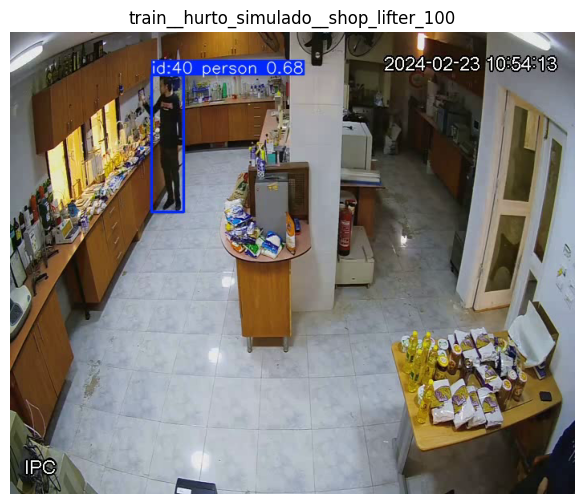

In [11]:
preview_candidates = sorted(OUTPUT_DIR.rglob("tracking_preview.mp4"))

if not preview_candidates:
    print("No hay previews guardados todavía.")
else:
    preview_path = preview_candidates[8]
    capture = cv2.VideoCapture(str(preview_path))
    capture.set(cv2.CAP_PROP_POS_FRAMES, 36)
    ok, frame = capture.read()
    capture.release()

    if ok:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(frame_rgb)
        plt.title(preview_path.parent.name)
        plt.axis("off")
        plt.show()
    else:
        print(f"No se pudo leer el preview: {preview_path}")